CIFAR-10: image classification of real-world images (airplane, car, bird, cat, ...) using a CNN.

the class mapping is:

0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()

In [3]:
print("Training images:",X_train.shape)
print("Training labels:",y_train.shape)

print("Test images:",X_test.shape)
print("Test labels:",y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [4]:
X_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

(50000, 1) means the data is arranged as a 2-dimensional array:

50000 rows × 1 column

So it looks conceptually like:

[ [6],
  [2],
  [9],
  [4],
  ... ]

Each row contains one value, so each label is wrapped inside a one-element array.
That's why:

y_train[0]      → [6]
y_train[0][0]   → 6



Whereas (50000,) means a 1-dimensional array:
[6, 2, 9, 4, ...]
so:
y_train[0] → 6


X_train → (60000, 28, 28) 
60000 images
   ↓
each image = 28 × 28

X_train[0]
means first image. One [0] is enough because you're selecting one item from the 60,000 images.



In CIFAR-10:
X_train → (50000, 32, 32, 3)
y_train → (50000, 1)

So:

X_train[0]      # first image
y_train[0]      # [6]
y_train[0][0]   # 6

CIFAR-10 images are RGB/color images, not grayscale.

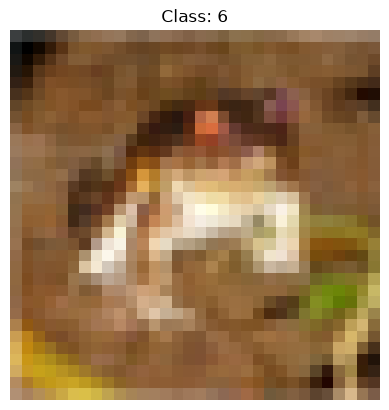

In [5]:
#look at one image:
plt.imshow(X_train[0])
plt.title(f"Class: {y_train[0][0]}")
plt.axis("off")
plt.show()

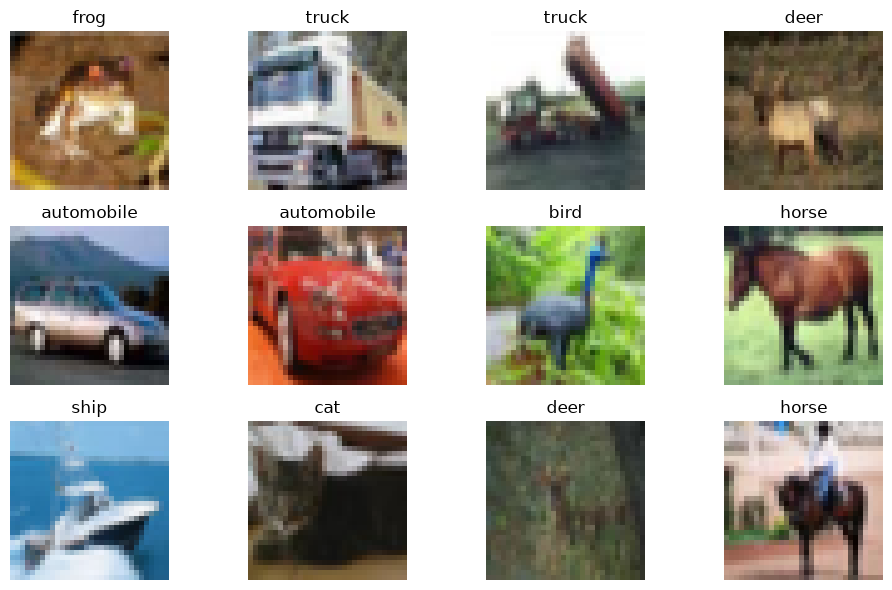

In [6]:
#This will show 12 images along with their actual class names instead of just numbers like 6.
#y_train[i] is still an array containing one value.

#class_names[6]
# "frog"
#So the flow is:

#y_train[i]       → [6]
#y_train[i][0]    → 6
#class_names[6]   → "frog"
#The 0 does not mean class zero. It means “take the first (and only) element of this array.”


class_names=["airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()





The titles are the actual CIFAR-10 class labels converted from numbers into names.

In [7]:
#normalize the images
#float32 is a good explicit practice, not a CNN requirement.It is a good consistent practice, even though it isn't strictly required if the data is already floating-point.


X_train = X_train.astype("float32") /255.0
X_test=X_test.astype('float32')/255.0

#We normalized the pixel values of every image in both X_train and X_test.

In [8]:
print(X_train.min())
print(X_train.max())

0.0
1.0


After normalization:
0.0 to 1.0
So every pixel in every CIFAR-10 image is now scaled to the 0–1 range.

In [10]:
from tensorflow.keras import layers,models
model=models.Sequential([
    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3),
                  ), 
                  layers.MaxPooling2D((2,2)),
                  layers.Conv2D(
                      64,
                      (3,3),
                      activation='relu'

                  ),
                  layers.MaxPooling2D((2,2)),
                  layers.Flatten(),
                  layers.Dense(64,activation='relu'),
                  layers.Dense(10,activation='softmax')
])


r:\C\PYTHON PROGRAMS\Deep Learning Proj 2 (CNN proj 1)\.venv-1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
